##Import Library

In [ ]:
import kagglehub
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
import random

from keras.models import Sequential, Model
from keras import layers
from keras.layers import (InputLayer, Rescaling, Conv2D, BatchNormalization,
                                     Activation, MaxPooling2D, GlobalAveragePooling2D,
                                     Dense, Dropout, RandomFlip, RandomRotation,
                                     RandomZoom, RandomTranslation, RandomContrast, Flatten, MaxPool2D)

from keras.applications import EfficientNetB0, DenseNet121
from sklearn.metrics import classification_report,confusion_matrix
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.regularizers import l2
from keras.losses import CategoricalCrossentropy, BinaryCrossentropy
from keras import regularizers
from keras.applications.densenet import preprocess_input as densenet_preprocess
import tensorflow_hub as hub
from tensorflow.keras.applications.densenet import preprocess_input

In [ ]:
import tensorflow as tf
print(tf.__version__)


2.19.0


##Import Dataset

In [ ]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


##EDA

In [ ]:
print("\nFolder structure:")
for dirname, dirs, filenames in os.walk(path):
    print(dirname)
    if len(dirs) > 0:
        print("  Subdirectories:", dirs)


Folder structure:
/kaggle/input/chest-xray-pneumonia
  Subdirectories: ['chest_xray']
/kaggle/input/chest-xray-pneumonia/chest_xray
  Subdirectories: ['chest_xray', '__MACOSX', 'val', 'test', 'train']
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray
  Subdirectories: ['val', 'test', 'train']
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val
  Subdirectories: ['PNEUMONIA', 'NORMAL']
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test
  Subdirectories: ['PNEUMONIA', 'NORMAL']
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train
  Subdirectories: ['PNEUMONIA', 'NORMAL']
/kaggle/input/chest-xray-pneumonia/chest_xray/chest_xray/train/PNEUMONIA
/kaggle/input/chest-xray-pneumoni

In [ ]:
train_dir = os.path.join(path, 'chest_xray', 'train')
val_dir = os.path.join(path, 'chest_xray', 'val')
test_dir = os.path.join(path, 'chest_xray', 'test')

In [ ]:
labels = ['PNEUMONIA', 'NORMAL']
img_size = 224

def get_training_data(data_dir):
    data = []
    for label in labels:
        path = os.path.join(data_dir, label)
        class_num = labels.index(label)
        for img in os.listdir(path):
            try:
                img_path = os.path.join(path, img)
                img_arr = cv2.imread(img_path)

                if img_arr is None:
                    print(f"Skipped: {img_path}")
                    continue

                img_arr = cv2.cvtColor(img_arr, cv2.COLOR_BGR2RGB)
                resized_arr = cv2.resize(img_arr, (img_size, img_size))
                data.append([resized_arr, class_num])
            except Exception as e:
                print(f"Error with {img}: {e}")

    return data

In [ ]:
train = get_training_data(train_dir)
test = get_training_data(test_dir)
val = get_training_data(val_dir)

In [ ]:
print("Shape of Training Data:", len(train))
print("Shape of Testing Data:", len(test))
print("Shape of validation Data:", len(val))

Shape of Training Data: 5216
Shape of Testing Data: 624
Shape of validation Data: 16


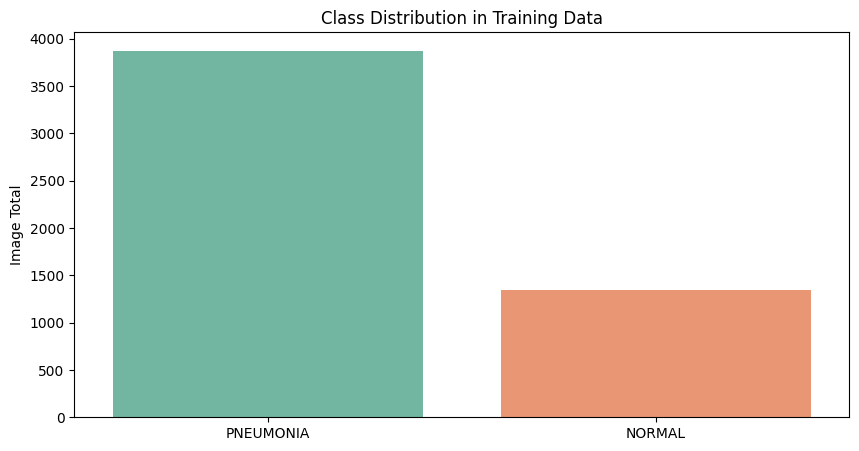

In [ ]:
class_counts = {
    'PNEUMONIA': len(os.listdir(os.path.join(train_dir, 'PNEUMONIA'))),
    'NORMAL': len(os.listdir(os.path.join(train_dir, 'NORMAL')))
}

plt.figure(figsize=(10, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()), hue=list(class_counts.keys()), palette='Set2', legend=False)
plt.title('Class Distribution in Training Data')
plt.ylabel('Image Total')
plt.show()

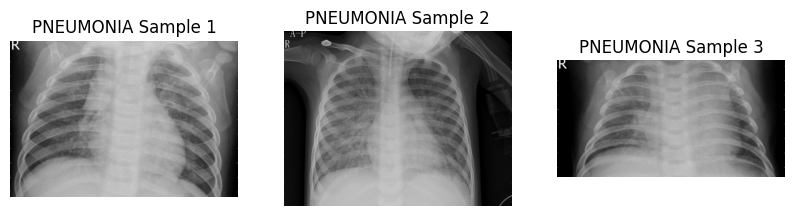

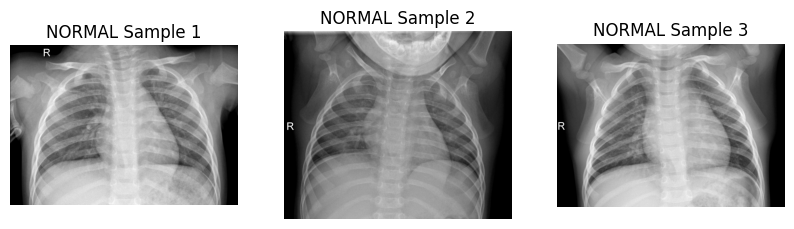

In [ ]:
def display_samples(data_dir, class_name, num_samples=3):
    plt.figure(figsize=(10, 5))
    class_path = os.path.join(data_dir, class_name)
    image_files = random.sample(os.listdir(class_path), num_samples)

    for i, img_file in enumerate(image_files):
        img_path = os.path.join(class_path, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img)
        plt.title(f"{class_name} Sample {i+1}")
        plt.axis('off')
    plt.show()

display_samples(train_dir, 'PNEUMONIA')
display_samples(train_dir, 'NORMAL')

##Preprocessing Data

In [ ]:
x_train, y_train, x_val, y_val, x_test, y_test = [], [], [], [], [], []

for feature, label in train:
    x_train.append(feature)
    y_train.append(label)

for feature, label in test:
    x_test.append(feature)
    y_test.append(label)

for feature, label in val:
    x_val.append(feature)
    y_val.append(label)

x_train = np.array(x_train, dtype='float32')
x_val   = np.array(x_val, dtype='float32')
x_test  = np.array(x_test, dtype='float32')

y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

print(x_train.shape)

(5216, 224, 224, 3)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

X_all = np.concatenate([x_train, x_val], axis=0)
Y_all = np.concatenate([y_train, y_val], axis=0)

x_train, x_val, y_train, y_val = train_test_split(
    X_all, Y_all, test_size=0.25, stratify=Y_all, random_state=42
)

# compute class weights after split
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.6737637362637363), 1: np.float64(1.9387351778656126)}


##Data Augmentation

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=False
)

## Model

In [ ]:
IMG_SIZE = 224
input_shape = (IMG_SIZE, IMG_SIZE, 3)

# Input
inputs = tf.keras.Input(shape=input_shape)

# Apply DenseNet-specific preprocessing
x = preprocess_input(inputs)

# Base model
base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_tensor=x
)

# Freeze base model for first stage
base_model.trainable = False

# Classification head
x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)  # binary: pneumonia vs normal

model = Model(inputs, outputs)

model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide         │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ true_divide[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ true_divide_1       │ (None, 224, 224,  │          0 │ add[0][0]         │
│ (TrueDivide)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ true_divide_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],    

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

In [ ]:
checkpoint_cb = ModelCheckpoint(
    'best_densenet121_pneumonia.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
BATCH_SIZE = 32
EPOCHS_STAGE1 = 10

history_stage1 = model.fit(
    datagen.flow(x_train, y_train, batch_size=BATCH_SIZE),
    epochs=EPOCHS_STAGE1,
    validation_data=(x_val, y_val),
    class_weight=class_weights,
    callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6873 - loss: 0.5986 - precision: 0.4254 - recall: 0.6752
Epoch 1: val_loss improved from inf to 0.40416, saving model to best_densenet121_pneumonia.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 1155s 9s/step - accuracy: 0.6879 - loss: 0.5977 - precision: 0.4262 - recall: 0.6760 - val_accuracy: 0.8318 - val_loss: 0.4042 - val_precision: 0.6058 - val_recall: 0.9941 - learning_rate: 0.0010
Epoch 2/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8637 - loss: 0.3148 - precision: 0.6783 - recall: 0.8938
Epoch 2: val_loss improved from 0.40416 to 0.29815, saving model to best_densenet121_pneumonia.keras
123/123 ━━━━━━━━━━━━━━━━━━━━ 1101s 9s/step - accuracy: 0.8638 - loss: 0.3147 - precision: 0.6785 - recall: 0.8939 - val_accuracy: 0.8899 - val_loss: 0.2981 - val_precision: 0.7040 - val_recall: 0.9881 - learning_rate: 0.0010
Epoch 3/10
123/123 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8809 - loss: 0.2705 - precision: 0.7037 - r

In [ ]:
test_loss, test_acc, test_prec, test_rec = model.evaluate(x_test, y_test, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_rec:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 125s 6s/step - accuracy: 0.9026 - loss: 0.2298 - precision: 0.3154 - recall: 0.3392
Test Loss: 0.2680
Test Accuracy: 0.8782
Test Precision: 0.8591
Test Recall: 0.8077


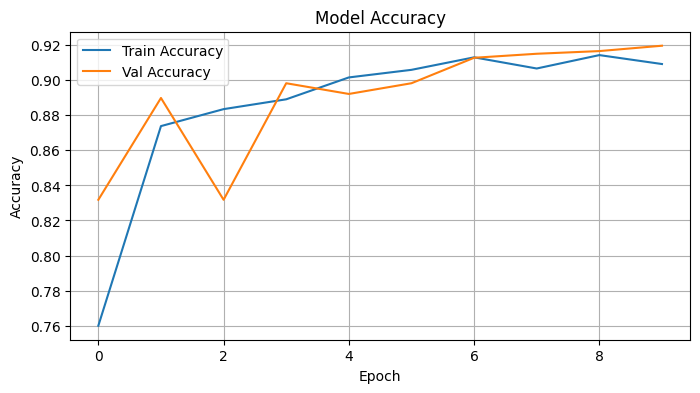

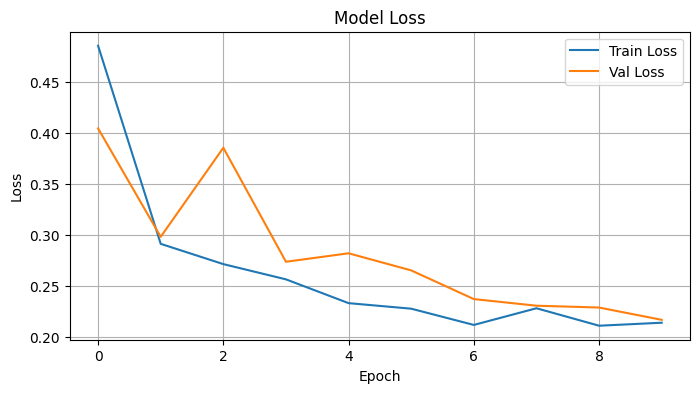

In [ ]:
def plot_training_history(history):
    # Accuracy
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()

    # Loss
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_training_history(history_stage1)